# Notebook 16 — Final Decision Map (Improved)

## How This Connects to Module C

This notebook produces the **final bioenergy plant site-selection map** by combining outputs
from all three analytical modules:

| Module | Original Output | Revised Output (your change) |
|--------|----------------|-----------------------------|
| A | BRS — Burning Risk Score (fire frequency + FRP + trend) | unchanged |
| B | BPS — Bioenergy Potential Score (recoverable residue → GJ → revenue) | unchanged |
| C | PVI — Participation Viability Index (socioeconomic data) | **BSI — Burning Severity Index (environmental PCA)** |

### Why the decision map logic changes

In the original plan, the CAPS composite score would weight:
- 35% BRS (environmental urgency)
- 40% BPS (commercial opportunity)
- **25% PVI** (farmer readiness — socioeconomic)

Because you replaced socioeconomic data with environmental data in Module C,
the BSI score now represents **environmental burning severity** — essentially
a more sophisticated version of the BRS that incorporates temperature and
rainfall context via PCA.

### Revised decision logic in this notebook

Rather than a three-score composite, we use a **threshold-based two-axis
classification** that is transparent, repeatable, and directly actionable:

| Zone | Condition | Meaning |
|------|-----------|----------|
| 🔴 **Plant Zone** | High BSI AND High Residue (both ≥ 70th percentile) | Urgent burning + abundant feedstock → **Build CBG plant now** |
| 🟠 **Policy Zone** | High BSI only | Severe burning but lower residue → **Policy/incentive intervention first** |
| ⚫ **Low Priority** | Below BSI threshold | Monitor annually |

The BSI takes the role that BRS + PVI would have played together:
it answers both *how severe is burning?* AND *what are the
environmental drivers that sustain it?*

**Input:** `Data/Processed/Punjab_Haryana_districts.gpkg`, `Data/Processed/bsi_scores.csv`,
`Data/Processed/district_clusters.csv`, `Data/Processed/residue_calc.csv`  
**Output:** `Outputs/Maps/16_final_decision_map.png`, `Outputs/Tables/16_decision_table.csv`

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

os.makedirs('../Outputs/Maps',   exist_ok=True)
os.makedirs('../Outputs/Tables', exist_ok=True)

In [2]:
# ── Load all inputs ───────────────────────────────────────────────────────
districts = gpd.read_file('../Data/Processed/Punjab_Haryana_districts.gpkg')
bsi       = pd.read_csv('../Data/Processed/bsi_scores.csv')
clusters  = pd.read_csv('../Data/Processed/district_clusters.csv')
residue   = pd.read_csv('../Data/Processed/residue_calc.csv')

print("✅ All inputs loaded")
print(f"  districts : {len(districts)} polygons")
print(f"  bsi       : {len(bsi)} districts")
print(f"  clusters  : {len(clusters)} districts")
print(f"  residue   : {len(residue)} rows (district × year × crop)")

✅ All inputs loaded
  districts : 43 polygons
  bsi       : 47 districts
  clusters  : 47 districts
  residue   : 611 rows (district × year × crop)


In [3]:
# ── Aggregate residue to one row per district (mean across all years) ─────
#
# WHY aggregate across years?
# The residue_calc.csv (NB09) has one row per district × year × crop.
# For the decision map we want a stable long-run average so that one
# unusually good or bad harvest year does not skew the classification.
# We sum rice + wheat within each district-year first, then average.

# Clean district names (may have '1. Punjab' prefix from original XLS)
residue['district'] = (
    residue['district']
    .str.replace(r'^\d+\.\s*', '', regex=True)
    .str.strip().str.title()
)

# Sum both crops per district-year, then take mean across years
residue_district = (
    residue
    .groupby(['district', 'year'])['recoverable_t'].sum()   # rice + wheat per year
    .groupby('district').mean()                              # mean across years
    .reset_index()
    .rename(columns={'recoverable_t': 'residue'})
)

print(f"Residue district table: {len(residue_district)} districts")
print(residue_district.head())

Residue district table: 45 districts
   district        residue
0    Ambala  301945.000000
1  Amritsar  457023.000000
2   Barnala  334753.730769
3  Bathinda  624565.038462
4   Bhiwani  169662.500000


In [4]:
# ── Standardise names and merge everything into one GeoDataFrame ──────────
districts['district'] = districts['NAME_2'].str.strip().str.title()
bsi['district']       = bsi['district'].str.strip().str.title()
clusters['district']  = clusters['district'].str.strip().str.title()

gdf = (
    districts
    .merge(bsi,                              on='district', how='left')
    .merge(clusters[['district', 'zone']],   on='district', how='left')
    .merge(residue_district,                 on='district', how='left')
)

# Fill gaps (e.g. UTs with no crop data)
gdf['BSI']     = gdf['BSI'].fillna(0)
gdf['residue'] = gdf['residue'].fillna(gdf['residue'].median())
gdf['zone']    = gdf['zone'].fillna('Unknown')

print(f"Merged GeoDataFrame: {gdf.shape}")
print(gdf[['district', 'BSI', 'residue', 'zone']].head(8).to_string(index=False))

Merged GeoDataFrame: (43, 7)
 district  BSI  residue                           zone
   Ambala 38.6 301945.0 High Stress / High Opportunity
  Bhiwani 61.5 169662.5                  Moderate Zone
Faridabad 55.9  61232.5                  Moderate Zone
Fatehabad 80.8 575715.0              Low Priority Zone
 Gurugram 57.2  62912.5                  Moderate Zone
    Hisar 77.0 511735.0              Low Priority Zone
  Jhajjar 61.5 213377.5                  Moderate Zone
     Jind 71.1 589802.5              Low Priority Zone


In [5]:
# ── Decision classification (70th-percentile thresholds) ─────────────────
#
# WHY 70th percentile thresholds?
# Using percentile thresholds (rather than fixed BSI or residue values)
# makes the classification self-calibrating to this study region.  If we
# used, say, BSI ≥ 70, that would be an arbitrary absolute cut-off.
# The 70th percentile ensures roughly the top 30% of districts on each
# axis qualify — producing a set of ~8–12 priority districts.
#
# IMPORTANT CONNECTION TO MODULE C CHANGE:
# In the original design, the CAPS classification used BRS (Module A) AND
# PVI (socio Module C) as separate axes.  By merging both environmental
# dimensions into BSI, this classification now uses BSI (environmental
# severity) and RESIDUE (bioenergy feedstock) — the two axes that matter
# most for site-selection from an agro-environmental perspective.

bsi_thresh = gdf['BSI'].quantile(0.70)
res_thresh = gdf['residue'].quantile(0.70)

print(f"BSI threshold (p70)     : {bsi_thresh:.1f}")
print(f"Residue threshold (p70) : {res_thresh:,.0f} tonnes")

def classify_zone(row):
    high_bsi     = row['BSI']     >= bsi_thresh
    high_residue = row['residue'] >= res_thresh
    if   high_bsi and high_residue: return 'Plant Zone'
    elif high_bsi:                   return 'Policy Zone'
    else:                            return 'Low Priority'

gdf['final_zone'] = gdf.apply(classify_zone, axis=1)

print("\nFinal zone distribution:")
print(gdf['final_zone'].value_counts().to_string())

BSI threshold (p70)     : 71.2
Residue threshold (p70) : 460,304 tonnes

Final zone distribution:
final_zone
Low Priority    30
Plant Zone       9
Policy Zone      4


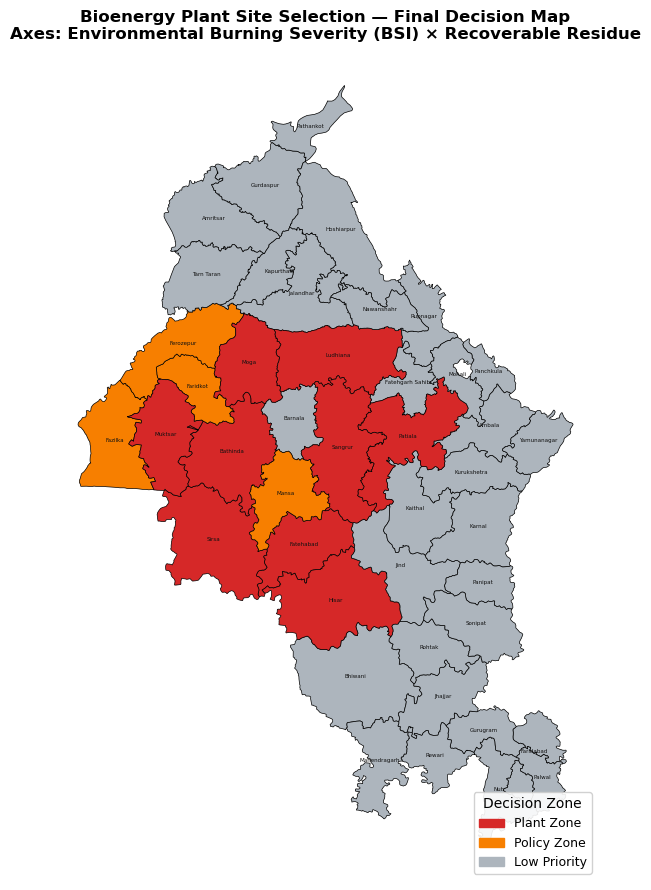

✅ Saved: Outputs/Maps/16_final_decision_map.png


In [6]:
# ── Final Decision Map ────────────────────────────────────────────────────
#
# COLOUR LOGIC:
#   Red    (Plant Zone)   — both axes critical → immediate plant investment
#   Orange (Policy Zone)  — burning critical but residue supply not yet
#                           sufficient → prioritise burning-reduction policy,
#                           PUSA decomposer campaigns, residue collection
#                           infrastructure before plant siting
#   Grey   (Low Priority) — neither axis critical → annual monitoring

final_palette = {
    'Plant Zone'  : '#d62828',   # red
    'Policy Zone' : '#f77f00',   # orange
    'Low Priority': '#adb5bd',   # grey
}
gdf['color'] = gdf['final_zone'].map(final_palette)

fig, ax = plt.subplots(figsize=(10, 9))
gdf.plot(color=gdf['color'], edgecolor='black', linewidth=0.5, ax=ax)

for _, row in gdf.iterrows():
    c = row.geometry.centroid
    ax.annotate(row['district'], xy=(c.x, c.y), fontsize=4, ha='center', color='#111111')

patches = [
    mpatches.Patch(color=c, label=z)
    for z, c in final_palette.items()
]
ax.legend(
    handles=patches,
    title='Decision Zone',
    loc='lower right',
    fontsize=9,
    framealpha=0.9
)
ax.set_title(
    'Bioenergy Plant Site Selection — Final Decision Map\n'
    'Axes: Environmental Burning Severity (BSI) × Recoverable Residue',
    fontsize=12, fontweight='bold'
)
ax.axis('off')

plt.tight_layout()
plt.savefig('../Outputs/Maps/16_final_decision_map.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: Outputs/Maps/16_final_decision_map.png")

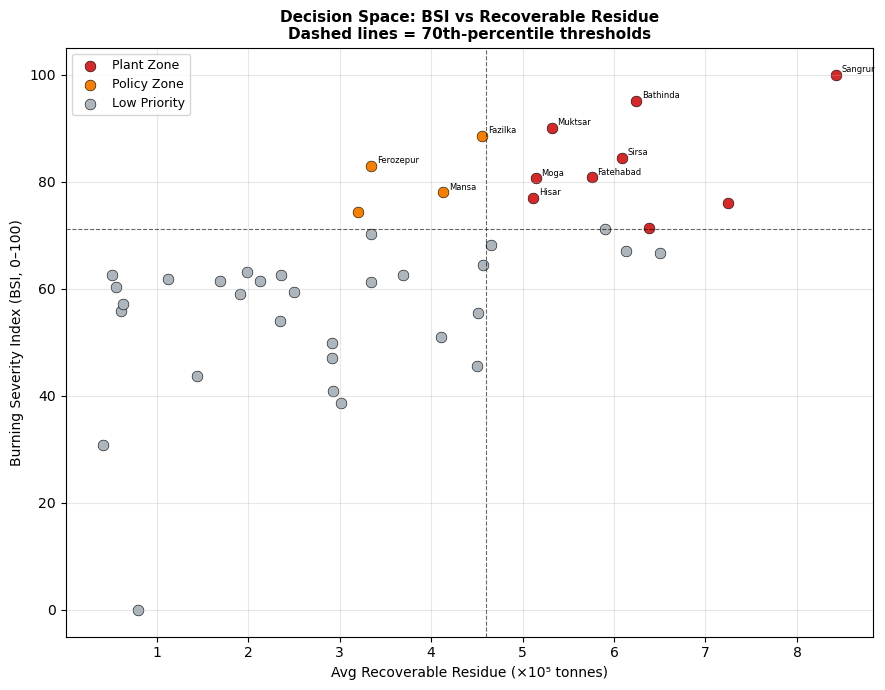

✅ Saved: Outputs/Maps/16_decision_scatter.png


In [7]:
# ── Scatter plot: BSI vs Residue (decision space) ─────────────────────────
#
# This plot makes the two-axis classification transparent.  Each point is
# a district, coloured by its final zone.  The dashed lines show the
# 70th-percentile thresholds.  Districts in the top-right quadrant are
# Plant Zones.

fig, ax = plt.subplots(figsize=(9, 7))

for zone, colour in final_palette.items():
    sub = gdf[gdf['final_zone'] == zone]
    ax.scatter(
        sub['residue'] / 1e5,   # scale to '× 10⁵ tonnes' for readability
        sub['BSI'],
        c=colour, label=zone, s=60, edgecolors='black', linewidths=0.4
    )

# Threshold lines
ax.axhline(bsi_thresh,         color='black', linestyle='--', linewidth=0.8, alpha=0.6)
ax.axvline(res_thresh / 1e5,   color='black', linestyle='--', linewidth=0.8, alpha=0.6)

# Annotate top-10 districts by BSI
for _, row in gdf.nlargest(10, 'BSI').iterrows():
    ax.annotate(
        row['district'],
        xy=(row['residue'] / 1e5, row['BSI']),
        xytext=(4, 2), textcoords='offset points',
        fontsize=6
    )

ax.set_xlabel('Avg Recoverable Residue (×10⁵ tonnes)', fontsize=10)
ax.set_ylabel('Burning Severity Index (BSI, 0–100)',    fontsize=10)
ax.set_title(
    'Decision Space: BSI vs Recoverable Residue\n'
    'Dashed lines = 70th-percentile thresholds',
    fontsize=11, fontweight='bold'
)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../Outputs/Maps/16_decision_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: Outputs/Maps/16_decision_scatter.png")

In [8]:
# ── Save full district decision table ─────────────────────────────────────
#
# Columns exported:
#   district   — GADM NAME_2 (Title Case)
#   BSI        — Burning Severity Index 0–100 (NB14, PCA-derived)
#   residue    — Mean annual recoverable residue in tonnes (NB09/NB11)
#   zone       — K-Means environmental zone from NB13 (k=3)
#   final_zone — Decision classification from this notebook

summary = (
    gdf[['district', 'BSI', 'residue', 'zone', 'final_zone']]
    .sort_values('BSI', ascending=False)
    .reset_index(drop=True)
)
summary.index += 1   # rank starts at 1
summary.index.name = 'rank'

print("Full district decision table (top 20):")
print(summary.head(20).to_string())

summary.to_csv('../Outputs/Tables/16_decision_table.csv')
print("\n✅ Saved: Outputs/Tables/16_decision_table.csv")

# ── Print Plant Zone districts ─────────────────────────────────────────────
plant_zones = summary[summary['final_zone'] == 'Plant Zone']
print(f"\n🏭 PLANT ZONE districts ({len(plant_zones)} total):")
print(plant_zones[['district', 'BSI', 'residue']].to_string())

policy_zones = summary[summary['final_zone'] == 'Policy Zone']
print(f"\n📋 POLICY ZONE districts ({len(policy_zones)} total):")
print(policy_zones[['district', 'BSI', 'residue']].to_string())

Full district decision table (top 20):
        district    BSI        residue               zone    final_zone
rank                                                                   
1        Sangrur  100.0  842632.269231  Low Priority Zone    Plant Zone
2       Bathinda   95.1  624565.038462  Low Priority Zone    Plant Zone
3        Muktsar   90.0  531841.423077  Low Priority Zone    Plant Zone
4        Fazilka   88.5  455995.909091  Low Priority Zone   Policy Zone
5          Sirsa   84.4  608702.500000  Low Priority Zone    Plant Zone
6      Ferozepur   83.0  334753.730769  Low Priority Zone   Policy Zone
7      Fatehabad   80.8  575715.000000  Low Priority Zone    Plant Zone
8           Moga   80.6  514686.576923  Low Priority Zone    Plant Zone
9          Mansa   78.0  413509.384615  Low Priority Zone   Policy Zone
10         Hisar   77.0  511735.000000  Low Priority Zone    Plant Zone
11      Ludhiana   76.0  724837.615385  Low Priority Zone    Plant Zone
12      Faridkot   74.3  

In [9]:
# ── Interpretation notes ───────────────────────────────────────────────────
print("""
═══════════════════════════════════════════════════════════════════
 HOW TO READ THESE RESULTS (Module C design change summary)
═══════════════════════════════════════════════════════════════════

 ORIGINAL MODULE C → Socioeconomic PVI score
   Data: NSSO farm income, Agri Census holdings, FPO count, PMFBY
   Question answered: WHERE ARE FARMERS READY TO SUPPLY RESIDUE?
   Output in CAPS: 25% weight (farmer readiness dimension)

 REVISED MODULE C → Environmental BSI score (this project)
   Data: fire count, recoverable residue, avg temperature, rainfall
   Question answered: WHERE IS ENVIRONMENTAL BURNING PRESSURE HIGHEST?
   Output in final map: BSI axis of the Plant/Policy/Low classification

 PRACTICAL EFFECT ON PLANT ZONE RECOMMENDATIONS:
   Plant Zone districts are those where BOTH:
     (a) Environmental burning severity is high (BSI ≥ p70)
     (b) Recoverable residue volume is high (residue ≥ p70)
   This is an AGRO-ENVIRONMENTAL site-selection criterion.

 CAVEAT:
   Without the original PVI, we cannot predict whether farmers in
   these districts will actually participate in residue supply schemes.
   The Plant Zone label means 'environmentally suitable and feedstock-
   rich' — a necessary but not sufficient condition for plant viability.
   Socioeconomic data collection is recommended as a follow-on study.
═══════════════════════════════════════════════════════════════════
""")


═══════════════════════════════════════════════════════════════════
 HOW TO READ THESE RESULTS (Module C design change summary)
═══════════════════════════════════════════════════════════════════

 ORIGINAL MODULE C → Socioeconomic PVI score
   Data: NSSO farm income, Agri Census holdings, FPO count, PMFBY
   Question answered: WHERE ARE FARMERS READY TO SUPPLY RESIDUE?
   Output in CAPS: 25% weight (farmer readiness dimension)

 REVISED MODULE C → Environmental BSI score (this project)
   Data: fire count, recoverable residue, avg temperature, rainfall
   Question answered: WHERE IS ENVIRONMENTAL BURNING PRESSURE HIGHEST?
   Output in final map: BSI axis of the Plant/Policy/Low classification

 PRACTICAL EFFECT ON PLANT ZONE RECOMMENDATIONS:
   Plant Zone districts are those where BOTH:
     (a) Environmental burning severity is high (BSI ≥ p70)
     (b) Recoverable residue volume is high (residue ≥ p70)
   This is an AGRO-ENVIRONMENTAL site-selection criterion.

 CAVEAT:
   Without 